
## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##2.Load Dataset

In [ ]:
df = pd.read_csv('/content/ecommerce_customer_data_large.csv')

In [ ]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [ ]:
df.shape

(250000, 13)

In [ ]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [ ]:
df.dtypes

,0
Customer ID,int64
Purchase Date,object
Product Category,object
Product Price,int64
Quantity,int64
Total Purchase Amount,int64
Payment Method,object
Customer Age,int64
Returns,float64
Customer Name,object


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# 3. Data Cleaning

In [ ]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [ ]:
df['Purchase Date'].dtype

dtype('<M8[ns]')

In [ ]:
df['Returns'].value_counts(dropna=False)

,count
Returns,
1.0,101476
0.0,101142
NaN,47382


In [ ]:
df['Returns'] = df['Returns'].fillna(0)

In [ ]:
df['Returns'].isnull().sum()

np.int64(0)

In [ ]:
(df['Customer Age'] == df['Age']).mean()

np.float64(1.0)

In [ ]:
df = df.drop(columns=['Age'])

In [ ]:
df[['Product Price',
   'Quantity',
   'Total Purchase Amount',
   'Customer Age']].describe()

,Product Price,Quantity,Total Purchase Amount,Customer Age
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,254.742724,3.004936,2725.385196,43.798276
std,141.738104,1.414737,1442.576095,15.364915
min,10.000000,1.000000,100.000000,18.000000
25%,132.000000,2.000000,1476.000000,30.000000
50%,255.000000,3.000000,2725.000000,44.000000
75%,377.000000,4.000000,3975.000000,57.000000
max,500.000000,5.000000,5350.000000,70.000000


# 4. Exploratory Data Analysis

In [ ]:
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 49661


In [ ]:
total_transactions = len(df)

print("Total Transactions:", total_transactions)

Total Transactions: 250000


In [ ]:
total_revenue = df['Total Purchase Amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 681346299


In [ ]:
average_purchase = df['Total Purchase Amount'].mean()

print("Average Purchase Amount:", average_purchase)

Average Purchase Amount: 2725.385196


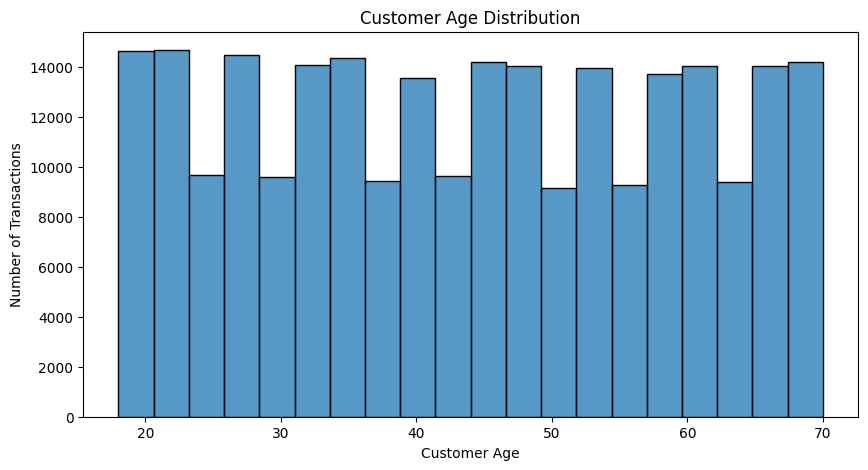

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='Customer Age', bins=20)

plt.title('Customer Age Distribution')
plt.xlabel('Customer Age')
plt.ylabel('Number of Transactions')

plt.show()

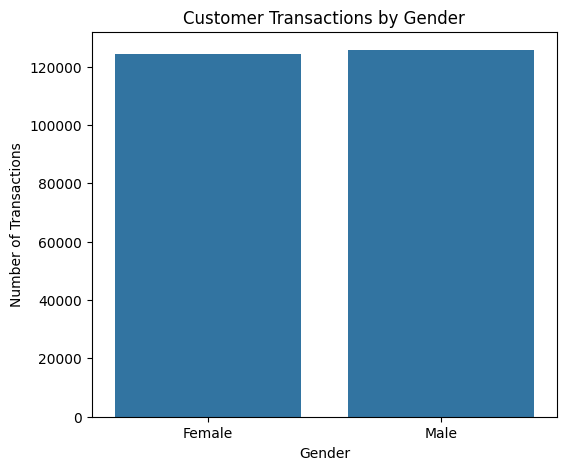

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender')

plt.title('Customer Transactions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')

plt.show()

In [ ]:
df['Product Category'].value_counts()

,count
Product Category,
Electronics,62630
Clothing,62581
Home,62542
Books,62247


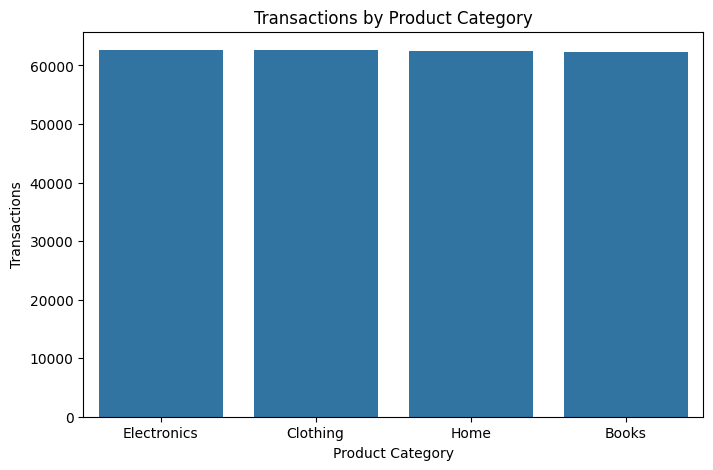

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Product Category',
    order=df['Product Category'].value_counts().index
)

plt.title('Transactions by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Transactions')

plt.show()

In [ ]:
category_revenue = (
    df.groupby('Product Category')['Total Purchase Amount']
      .sum()
      .sort_values(ascending=False)
)

category_revenue

,Total Purchase Amount
Product Category,
Home,171138916
Clothing,170716122
Electronics,170146025
Books,169345236


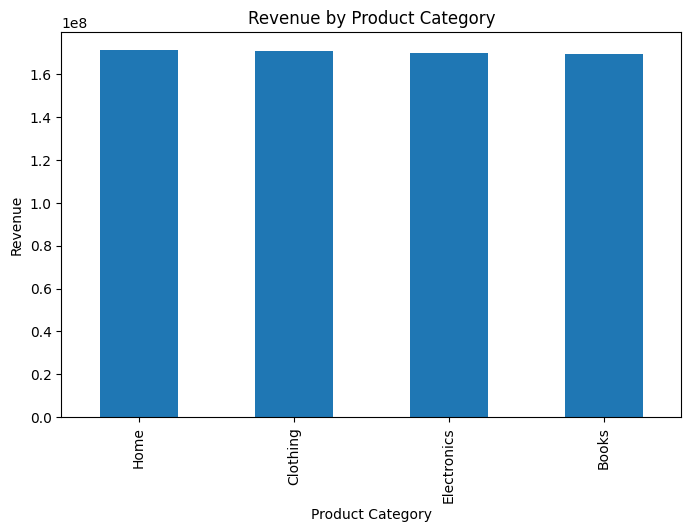

In [ ]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.show()

In [ ]:
df['Payment Method'].value_counts()

,count
Payment Method,
Credit Card,83547
PayPal,83441
Cash,83012


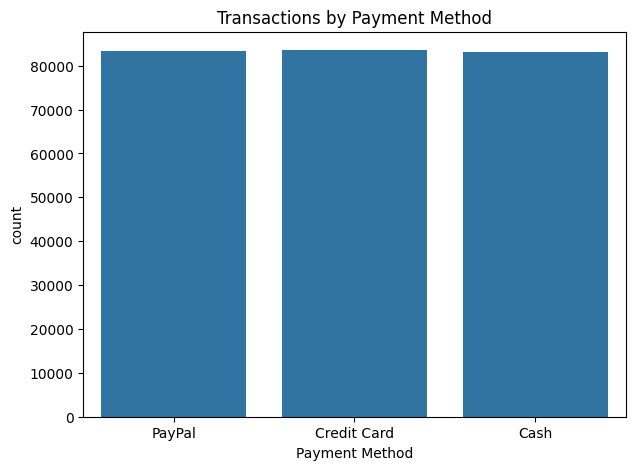

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Payment Method')

plt.title('Transactions by Payment Method')

plt.show()

Create Month/Year

In [ ]:
df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month

In [ ]:
df['Month_Year'] = df['Purchase Date'].dt.to_period('M')

Monthly Revenue

In [ ]:
monthly_revenue = (
    df.groupby('Month_Year')['Total Purchase Amount']
      .sum()
)

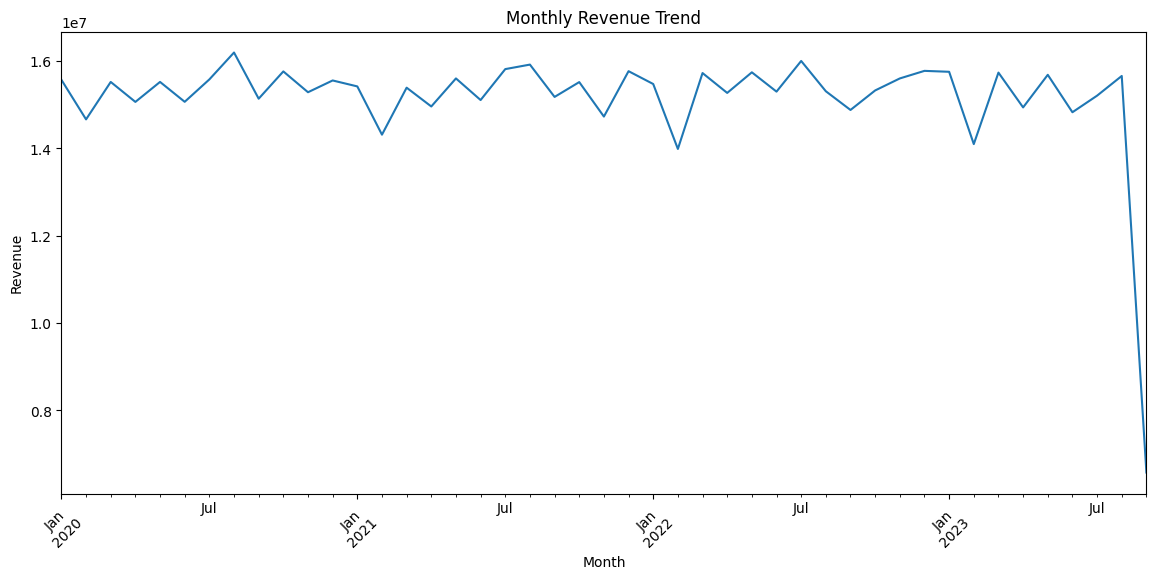

In [ ]:
plt.figure(figsize=(14,6))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

Monthly Transactions

In [ ]:
monthly_transactions = (
    df.groupby('Month_Year')
      .size()
)

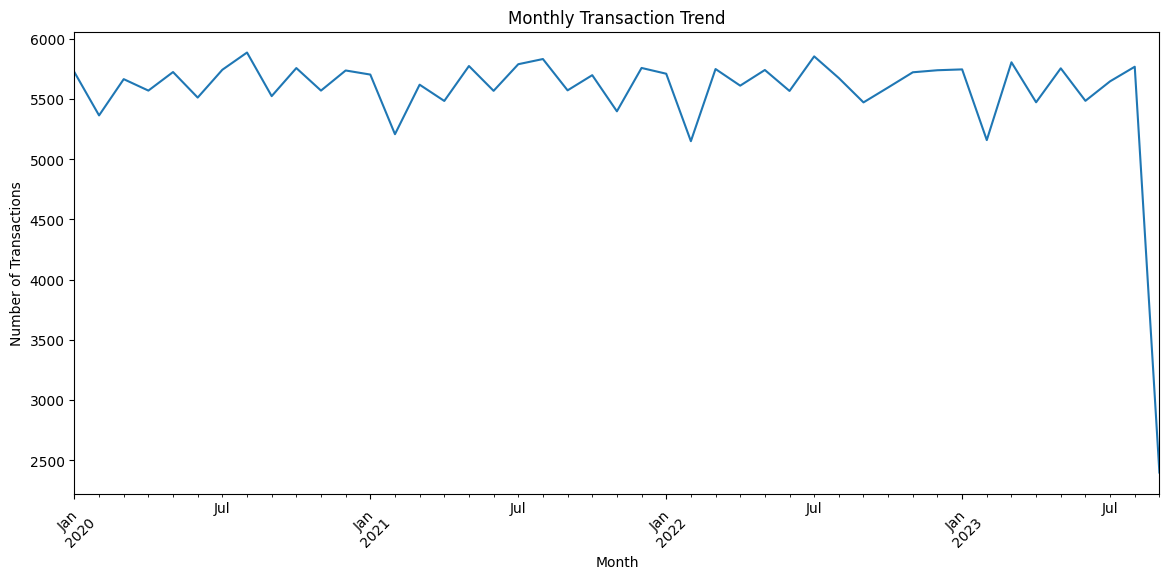

In [ ]:
plt.figure(figsize=(14,6))

monthly_transactions.plot()

plt.title('Monthly Transaction Trend')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)

plt.show()

# 5. Feature Engineering

Create Date Features


In [ ]:
df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month
df['Day'] = df['Purchase Date'].dt.day
df['Day_of_Week'] = df['Purchase Date'].dt.day_name()

Create Age Groups

In [ ]:
df['Age_Group'] = pd.cut(
    df['Customer Age'],
    bins=[17, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

##6. RFM ANALYSIS

Create analysis date

In [ ]:
analysis_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

print(analysis_date)

2023-09-14 18:42:49


Calculate RFM

In [ ]:
rfm = df.groupby('Customer ID').agg(
    Recency=('Purchase Date',
             lambda x: (analysis_date - x.max()).days),

    Frequency=('Customer ID', 'count'),

    Monetary=('Total Purchase Amount', 'sum')
).reset_index()

In [ ]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,1,289,3,6290
1,2,73,6,16481
2,3,223,4,9423
3,4,442,5,7826
4,5,425,5,9769


RFM SCORING

In [ ]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int)
    + rfm['F_Score'].astype(int)
    + rfm['M_Score'].astype(int)
)

##7. CUSTOMER SEGMENTATION

In [ ]:
def segment_customer(score):

    if score >= 13:
        return 'Champions'

    elif score >= 10:
        return 'Loyal Customers'

    elif score >= 7:
        return 'Potential Loyalists'

    elif score >= 5:
        return 'At Risk'

    else:
        return 'Lost Customers'

In [ ]:
rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
Potential Loyalists,13357
Loyal Customers,13337
Champions,9583
At Risk,7102
Lost Customers,6282


Visualize Segments

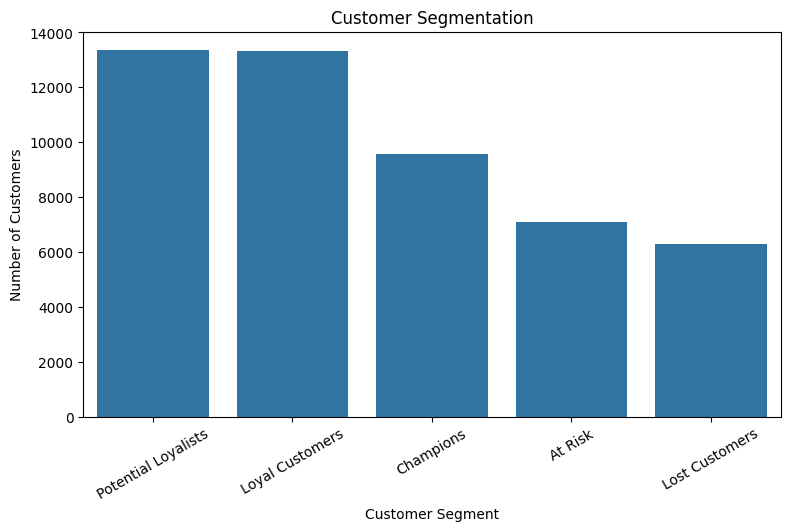

In [ ]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30)

plt.show()

##8. SEGMENT PROFILING

In [ ]:
segment_profile = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,7102,370.88,3.26,8306.55
Champions,9583,76.81,7.89,22506.30
Lost Customers,6282,654.15,2.18,5338.36
Loyal Customers,13337,175.51,6.00,16566.33
Potential Loyalists,13357,240.15,4.31,11394.37


##9. CHURN ANALYSIS

In [ ]:
churn_counts = df['Churn'].value_counts()

churn_counts

,count
Churn,
0,199870
1,50130


In [ ]:
churn_counts = df['Churn'].value_counts()

churn_counts

,count
Churn,
0,199870
1,50130


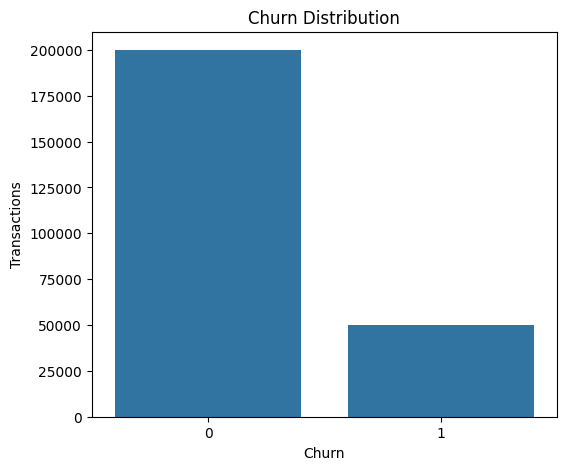

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Churn')

plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Transactions')

plt.show()

##10. CONNECT RFM WITH CHURN

In [ ]:
customer_churn = (
    df.groupby('Customer ID')['Churn']
      .max()
      .reset_index()
)

In [ ]:
rfm = rfm.merge(
    customer_churn,
    on='Customer ID',
    how='left'
)

In [ ]:
churn_by_segment = (
    rfm.groupby('Segment')['Churn']
       .mean()
       .sort_values(ascending=False)
)

churn_by_segment

,Churn
Segment,
Champions,0.205885
Lost Customers,0.202802
At Risk,0.202478
Loyal Customers,0.199220
Potential Loyalists,0.193681


In [ ]:
churn_by_segment * 100

,Churn
Segment,
Champions,20.588542
Lost Customers,20.280166
At Risk,20.247818
Loyal Customers,19.922021
Potential Loyalists,19.368122


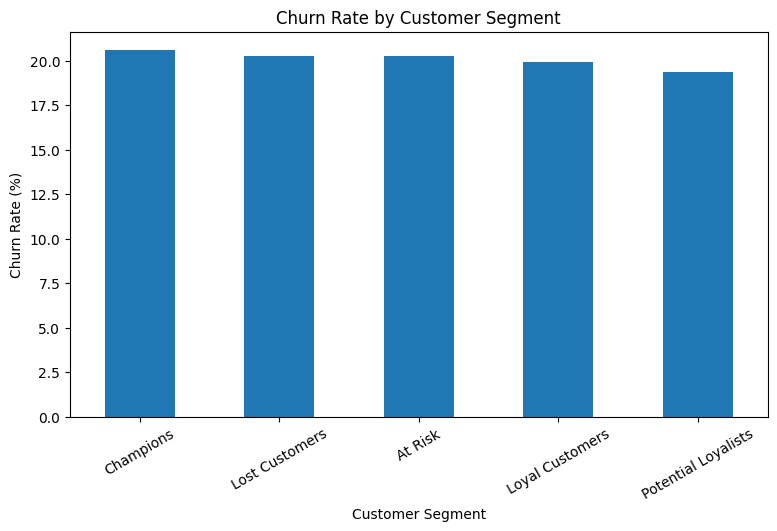

In [ ]:
plt.figure(figsize=(9,5))

(churn_by_segment * 100).plot(kind='bar')

plt.title('Churn Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=30)

plt.show()

##11. RETENTION ANALYSIS

In [ ]:
purchase_counts = df.groupby('Customer ID').size()

repeat_customers = (purchase_counts > 1).sum()

total_customers = purchase_counts.count()

repeat_rate = repeat_customers / total_customers * 100

print("Repeat Customer Rate:", round(repeat_rate, 2), "%")

Repeat Customer Rate: 96.67 %


In [ ]:
customer_type = purchase_counts.apply(
    lambda x: 'Repeat Customer' if x > 1 else 'One-time Customer'
)

customer_type.value_counts()

,count
Repeat Customer,48008
One-time Customer,1653


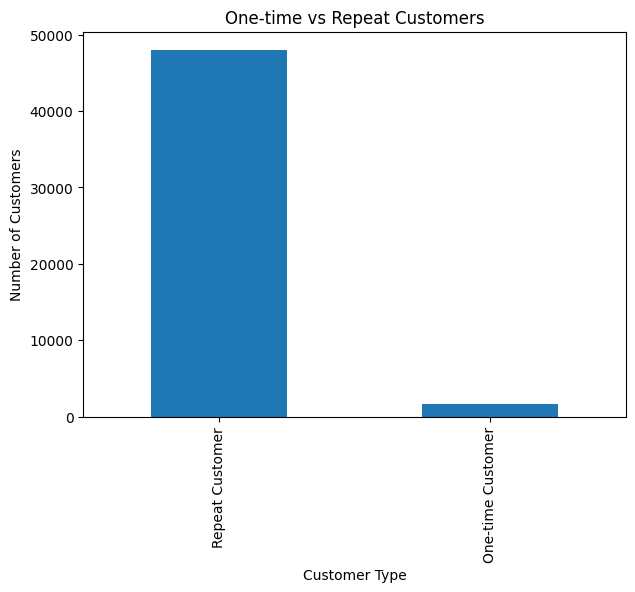

In [ ]:
plt.figure(figsize=(7,5))

customer_type.value_counts().plot(kind='bar')

plt.title('One-time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.show()

# 12. Key Business Insights

Segment profile

In [ ]:
segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,7102,370.88,3.26,8306.55
Champions,9583,76.81,7.89,22506.30
Lost Customers,6282,654.15,2.18,5338.36
Loyal Customers,13337,175.51,6.00,16566.33
Potential Loyalists,13357,240.15,4.31,11394.37


Customer segments

In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
Potential Loyalists,13357
Loyal Customers,13337
Champions,9583
At Risk,7102
Lost Customers,6282


Churn by segment

In [ ]:
(churn_by_segment * 100).round(2)

,Churn
Segment,
Champions,20.59
Lost Customers,20.28
At Risk,20.25
Loyal Customers,19.92
Potential Loyalists,19.37


Repeat customer rate

In [ ]:
print("Repeat Customer Rate:", round(repeat_rate, 2), "%")

Repeat Customer Rate: 96.67 %


In [ ]:
print("Largest Segment:")
print(rfm['Segment'].value_counts().idxmax())

print("\nHighest Churn Segment:")
print((churn_by_segment * 100).idxmax())

print("\nHighest Revenue Segment:")
print(segment_profile['Avg_Monetary'].idxmax())

Largest Segment:
Potential Loyalists

Highest Churn Segment:
Champions

Highest Revenue Segment:
Champions


In [ ]:
print("CUSTOMER SEGMENTS")
print(rfm['Segment'].value_counts())

print("\nSEGMENT PROFILE")
display(segment_profile)

print("\nCHURN RATE BY SEGMENT")
display((churn_by_segment * 100).round(2))

print("\nREPEAT CUSTOMER RATE")
print(round(repeat_rate, 2), "%")

CUSTOMER SEGMENTS
Segment
Potential Loyalists    13357
Loyal Customers        13337
Champions               9583
At Risk                 7102
Lost Customers          6282
Name: count, dtype: int64

SEGMENT PROFILE


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,7102,370.88,3.26,8306.55
Champions,9583,76.81,7.89,22506.30
Lost Customers,6282,654.15,2.18,5338.36
Loyal Customers,13337,175.51,6.00,16566.33
Potential Loyalists,13357,240.15,4.31,11394.37



CHURN RATE BY SEGMENT


,Churn
Segment,
Champions,20.59
Lost Customers,20.28
At Risk,20.25
Loyal Customers,19.92
Potential Loyalists,19.37



REPEAT CUSTOMER RATE
96.67 %


### Insight 1: Customer Segmentation

RFM analysis divided the 49,661 customers into five segments: Potential
Loyalists, Loyal Customers, Champions, At Risk, and Lost Customers.

Potential Loyalists form the largest segment with 13,357 customers,
followed closely by Loyal Customers with 13,337 customers. Champions
account for 9,583 customers, while 7,102 customers are classified as
At Risk and 6,282 as Lost Customers.

This indicates that a significant portion of the customer base has
potential for further engagement and loyalty development.



### Insight 2: Champions are the High-Value Customers

Champions have the strongest purchasing behavior, with an average
frequency of 7.89 purchases and average monetary value of 22,506.30.

They also have the lowest average recency of 76.81 days, indicating
that they have purchased more recently than the other customer
segments.

Therefore, Champions represent the most valuable customer segment
and should be prioritized for retention and loyalty initiatives.


### Insight 3: Potential Loyalists Represent the Largest Opportunity

Potential Loyalists are the largest customer segment, containing
13,357 customers.

Their average frequency is 4.31 purchases and their average monetary
value is 11,394.37. This indicates that these customers already show
meaningful purchasing activity but have not yet reached the stronger
Loyal Customer or Champion segments.

Targeted engagement and loyalty campaigns could help convert these
customers into higher-value customers.

### Insight 4: Churn Risk Is Highest Among Champions

Champions have the highest churn rate at 20.59%, followed by Lost
Customers at 20.28% and At Risk customers at 20.25%.

The high churn rate among Champions is particularly important because
Champions also have the highest average monetary value.

Therefore, losing Champion customers could have a significant impact
on revenue, making Champion retention a major business priority.


### Insight 5: Strong Repeat Purchase Behavior

The repeat customer rate is 96.67%, indicating that the majority of
customers have made more than one purchase.

This suggests strong repeat-purchase behavior within the dataset.
However, the relatively high churn rates across customer segments
indicate that repeat purchasing and churn prevention should both be
monitored.


### Insight 6: Loyal Customers Provide a Strong Revenue Base

Loyal Customers represent 13,337 customers and have an average
frequency of 6.00 purchases and an average monetary value of
16,566.33.

This makes them an important revenue-generating segment. Maintaining
their engagement and encouraging them toward Champion-level behavior
could increase customer lifetime value.


### Overall Business Insight

The analysis shows that Alfido Tech has a large base of Potential
Loyalists and Loyal Customers, providing significant opportunities
for customer development.

At the same time, Champions have the highest monetary value but also
the highest churn rate. Therefore, Alfido Tech should focus on both
converting Potential Loyalists into Loyal Customers and protecting
high-value Champion customers from churn.

# 13. Actionable Recommendations for Alfido Tech

1. Protect Champion Customers

Target Champions with personalized loyalty rewards, exclusive offers, early access to products, and personalized recommendations. Since Champions have the highest average monetary value of 22,506.30 and the highest churn rate of 20.59%, retaining this group should be a priority.

2. Convert Potential Loyalists

Potential Loyalists are the largest segment with 13,357 customers. Alfido Tech should use targeted promotions, loyalty points, personalized recommendations, and repeat-purchase incentives to move these customers toward the Loyal Customer segment.

3. Strengthen Loyal Customer Engagement

Loyal Customers have an average frequency of 6 purchases and average monetary value of 16,566.33. Loyalty programs, personalized offers, and cross-selling can encourage these customers to increase their purchase frequency and move toward the Champion segment.

4. Run Win-Back Campaigns for At Risk and Lost Customers

At Risk and Lost Customers have churn rates of 20.25% and 20.28%, respectively. Alfido Tech should use targeted win-back campaigns, limited-time offers, and personalized product recommendations to encourage inactive customers to return.

5. Use Segment-Based Personalization

Instead of using the same marketing strategy for every customer, Alfido Tech should personalize campaigns according to RFM segments. Champions should receive loyalty benefits, Potential Loyalists should receive conversion incentives, while At Risk and Lost Customers should receive re-engagement campaigns.

# 14. Conclusion

The Customer Behaviour Analysis identified five major customer
segments using RFM analysis: Champions, Loyal Customers, Potential
Loyalists, At Risk, and Lost Customers.

The analysis found that Potential Loyalists represent the largest
customer segment with 13,357 customers, while Champions have the
highest average monetary value of 22,506.30. However, Champions also
show the highest churn rate at 20.59%, making their retention an
important business priority.

The repeat customer rate of 96.67% indicates strong repeat-purchase
behavior. Alfido Tech can improve customer engagement by using
segment-specific marketing strategies, protecting high-value
customers, converting Potential Loyalists into Loyal Customers, and
re-engaging customers at risk of churn.

Overall, RFM-based segmentation provides Alfido Tech with a practical
framework for improving customer retention, engagement, and
long-term customer value.